# Look → compare → evaluate → discuss

**90-minute hands-on · real RGB previews · blocked comparison + ANCOVA decision · spatial diagnostics · CNN evaluation**

> **Small de-identified real-data subset:** 12 plots, two real 512 px RGB previews,
> no GPS, CRS, source IDs, or model weights.

**Today:** see the field first, choose a method from the question, check it, compare
treatments, evaluate predictions, and separate **Results** from **Discussion**.

**Google Colab:** choose **Runtime → Run all**. The notebook reads the small
teaching tables and RGB previews directly from GitHub.

| 0–15 | 15–25 | 25–35 | 35–55 | 55–65 | 65–78 | 78–90 |
|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| RGB + timeline | maps + zooms | choose a method | blocked model + ANCOVA | post hoc + space | CNN | write |

In [1]:
# Installs only missing packages (use requirements.txt for local setup).
import importlib.util, subprocess, sys

required = {
    "geopandas": "geopandas>=1.0,<2",
    "PIL": "pillow>=10,<13",
    "seaborn": "seaborn>=0.13,<1",
    "shapely": "shapely>=2.0,<3",
    "sklearn": "scikit-learn>=1.5,<2",
    "statsmodels": "statsmodels>=0.14,<0.15",
}
missing = [pkg for module, pkg in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

In [2]:
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import FancyBboxPatch, Patch
from PIL import Image
from scipy.stats import shapiro
from shapely import wkt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 105, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

COLORS = {"Control": "#5F6B7A", "Fungicide": "#009E73", "Inoculated": "#D55E00"}
MARKERS = {"Control": "o", "Fungicide": "s", "Inoculated": "^"}
LINESTYLES = {"Control": "-", "Fungicide": "--", "Inoculated": ":"}
ORDER = ["Control", "Fungicide", "Inoculated"]

In [3]:
# Local files first; raw GitHub files are the Colab fallback.
root = next((p for p in [Path(".."), Path(".")] if (p / "data").exists()), None)
raw = "https://raw.githubusercontent.com/Facuriy/agro-data-analysis-hands-on/v1.0.0"

def table(name):
    return pd.read_csv(root / "data" / name if root else f"{raw}/data/{name}")

def picture(name):
    if root:
        return np.asarray(Image.open(root / "assets" / name).convert("RGB"))
    return np.asarray(Image.open(BytesIO(urlopen(f"{raw}/assets/{name}").read())).convert("RGB"))

field = table("field_plots.csv")
events = table("field_events.csv")
cnn = table("cnn_model_outputs.csv")
rgb_early = picture("rgb_early_512.jpg")
rgb_late = picture("rgb_late_512.jpg")

field["treatment"] = pd.Categorical(field["treatment"], ORDER, ordered=True)
events["date"] = pd.to_datetime(events["date"])
sowing_date = events.loc[events["event_id"].eq("E01"), "date"].iloc[0]
calculated_das = (events["date"] - sowing_date).dt.days
assert calculated_das.eq(events["days_after_sowing"]).all(), "Check event dates or DAS"

def plot_gdf(column):
    geometry = field[column].map(wkt.loads)
    return gpd.GeoDataFrame(
        field.drop(columns=["polygon_early_px", "polygon_late_px"]),
        geometry=geometry,
        crs=None,
    )

plots_early = plot_gdf("polygon_early_px")
plots_late = plot_gdf("polygon_late_px")

def rgb_axis(ax, image, title=""):
    ax.imshow(image, origin="upper", extent=(0, 512, 512, 0), interpolation="nearest")
    ax.set(xlim=(0, 512), ylim=(512, 0), title=title, xticks=[], yticks=[])
    ax.set_aspect("equal")

print("Ready: 12 plots · 10 events · 2 image dates · 3 treatments · 4 blocks")
print("Date audit passed: every DAS value matches the recorded event date.")

Ready: 12 plots · 10 events · 2 image dates · 3 treatments · 4 blocks
Date audit passed: every DAS value matches the recorded event date.


## 1 · Look before testing

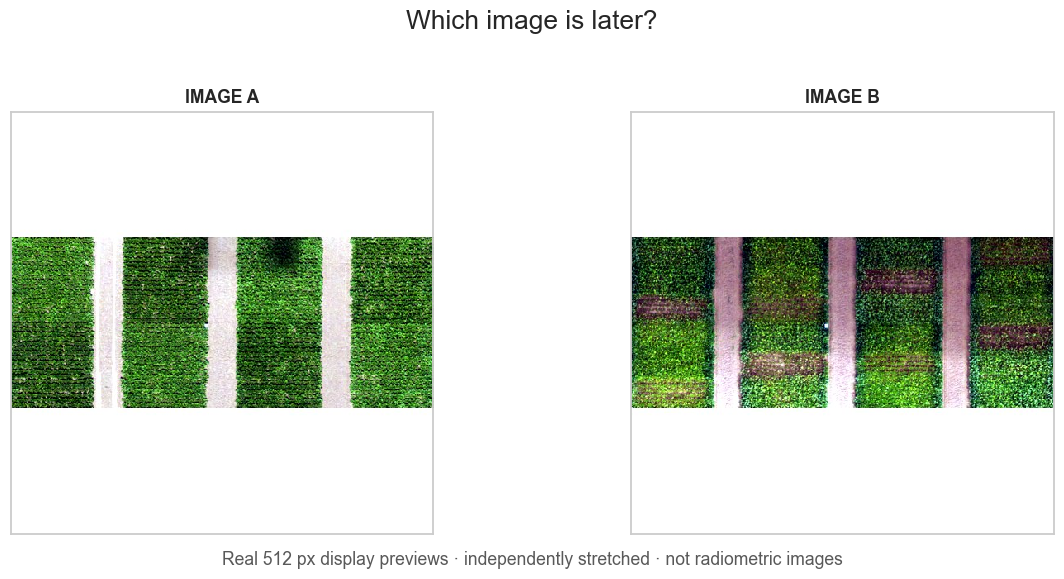

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
rgb_axis(axes[0], rgb_early, "IMAGE A")
rgb_axis(axes[1], rgb_late, "IMAGE B")
fig.suptitle("Which image is later?", fontsize=18, y=0.98)
fig.text(
    0.5,
    0.02,
    "Real 512 px display previews · independently stretched · not radiometric images",
    ha="center",
    color="0.35",
)
plt.tight_layout(rect=(0, .04, 1, .95))
plt.show()

**Reveal:** B is 3 September. The stronger visible canopy decline makes September a reasonable prediction for clearer separation. That is still a visual hypothesis—not statistical evidence.

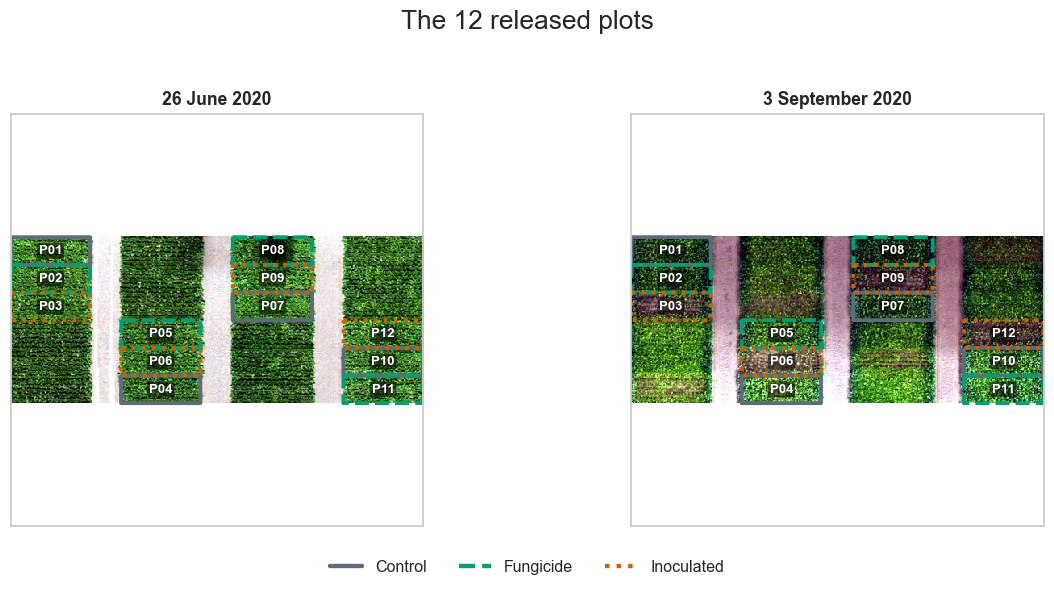

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, image, geo, title in [
    (axes[0], rgb_early, plots_early, "26 June 2020"),
    (axes[1], rgb_late, plots_late, "3 September 2020"),
]:
    rgb_axis(ax, image, title)
    for treatment, group in geo.groupby("treatment", observed=True):
        group.boundary.plot(
            ax=ax,
            color=COLORS[str(treatment)],
            linestyle=LINESTYLES[str(treatment)],
            linewidth=2.6,
        )
    for _, row in geo.iterrows():
        c = row.geometry.centroid
        ax.text(
            c.x,
            c.y,
            row.plot_id,
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            weight="bold",
            bbox=dict(boxstyle="round,pad=.14", fc="black", ec="none", alpha=.55),
        )

handles = [
    plt.Line2D([0], [0], color=COLORS[t], linestyle=LINESTYLES[t], lw=3, label=t)
    for t in ORDER
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("The 12 released plots", fontsize=18)
plt.tight_layout(rect=(0, .07, 1, .94))
plt.show()

### The timeline changes the analysis

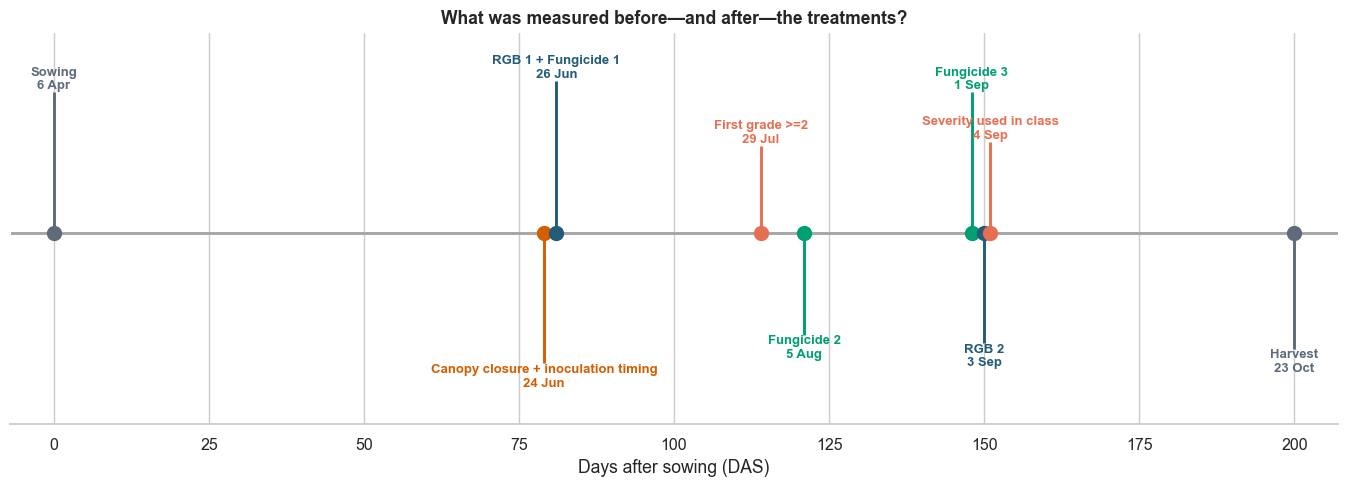

In [6]:
display_order = [
    "sowing", "closure", "june_overlap", "first_symptom",
    "fungicide_2", "fungicide_3", "rgb_2", "severity_class", "harvest",
]
display_heights = {
    "sowing": 1.00, "closure": -.92, "june_overlap": 1.08,
    "first_symptom": .62, "fungicide_2": -.72, "fungicide_3": 1.00,
    "rgb_2": -.78, "severity_class": .65, "harvest": -.82,
}
display_colors = {
    "sowing": "#5F6B7A", "closure": "#D55E00", "june_overlap": "#245B78",
    "first_symptom": "#E76F51", "fungicide_2": "#009E73",
    "fungicide_3": "#009E73", "rgb_2": "#245B78",
    "severity_class": "#E76F51", "harvest": "#5F6B7A",
}

# Two events on 26 June deliberately share one marker.
timeline = (
    events.groupby("display_group", as_index=False)
    .agg(
        date=("date", "first"),
        DAS=("days_after_sowing", "first"),
        label=("event_label", lambda values: " + ".join(values)),
    )
    .set_index("display_group")
    .loc[display_order]
    .reset_index()
)
timeline["height"] = timeline["display_group"].map(display_heights)
timeline["color"] = timeline["display_group"].map(display_colors)
timeline["date_label"] = timeline["date"].map(
    lambda value: f"{value.day} {value.strftime('%b')}"
)
timeline["plot_label"] = timeline["label"] + "\n" + timeline["date_label"]

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.axhline(0, color=".65", lw=2)
for row in timeline.itertuples():
    ax.vlines(row.DAS, 0, row.height, color=row.color, lw=2)
    ax.scatter(row.DAS, 0, s=90, color=row.color, zorder=3)
    ax.text(
        row.DAS, row.height, row.plot_label,
        ha="center", va="bottom" if row.height > 0 else "top",
        fontsize=9, weight="bold", color=row.color,
    )
ax.set(
    xlim=(-7, 207), ylim=(-1.35, 1.42),
    xlabel="Days after sowing (DAS)", yticks=[],
    title="What was measured before—and after—the treatments?",
)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

**Reveal: No.** The June image is two days after the recorded
canopy-closure/inoculation timing and shares a date with fungicide
application 1. The flight/application order within 26 June is unknown.
June green share can be a descriptor or conditional sensitivity
variable, but not a clean baseline for the total treatment effect.

Timeline provenance: [course experiment context](../instructor/experiment_context.md) · [2020 UAV campaign paper](https://arxiv.org/abs/2201.02885)

### Three variables, three roles

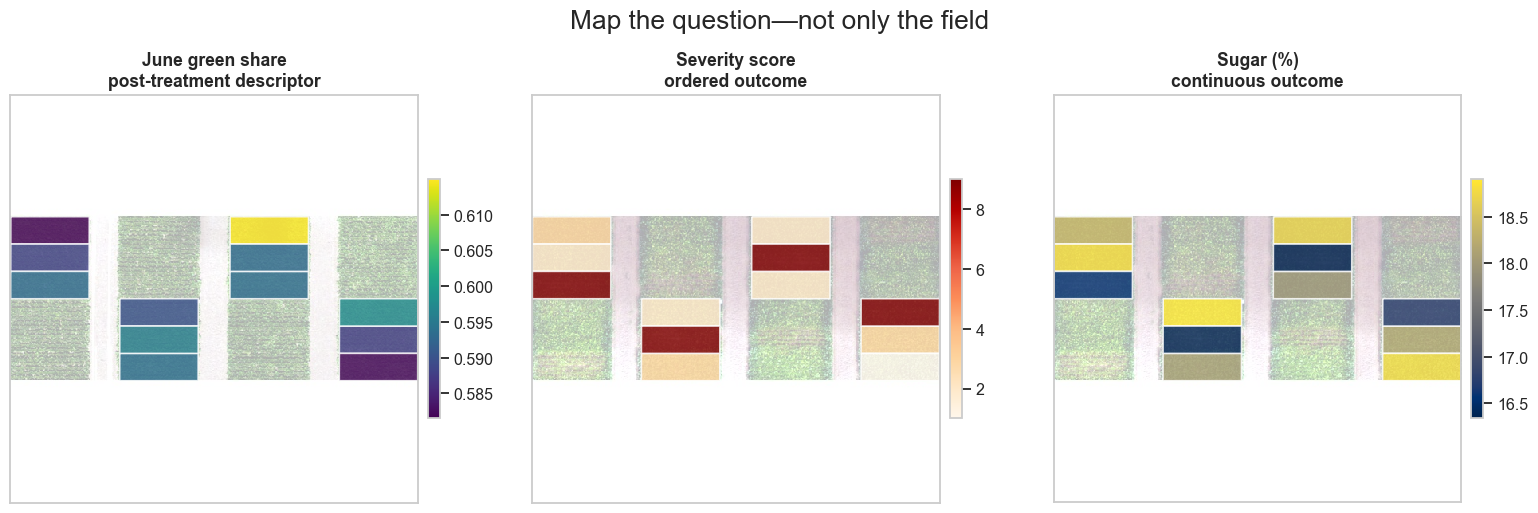

In [7]:
map_specs = [
    (plots_early, rgb_early, "early_green_share", "viridis", "June green share\npost-treatment descriptor"),
    (plots_late, rgb_late, "severity_sep04", "OrRd", "Severity score\nordered outcome"),
    (plots_late, rgb_late, "sugar_content_pct", "cividis", "Sugar (%)\ncontinuous outcome"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (geo, image, variable, cmap, title) in zip(axes, map_specs):
    rgb_axis(ax, image, title)
    ax.images[0].set_alpha(.32)
    geo.plot(
        ax=ax,
        column=variable,
        cmap=cmap,
        alpha=.82,
        edgecolor="white",
        linewidth=1.1,
        legend=True,
        legend_kwds={"shrink": .58, "pad": .02},
    )
    ax.set(xlim=(0, 512), ylim=(512, 0), xticks=[], yticks=[])
fig.suptitle("Map the question—not only the field", fontsize=18)
plt.tight_layout(rect=(0, 0, 1, .94))
plt.show()

> **Important:** green share is calculated from each display-stretched JPEG. It is useful for this visual exercise, but it is **not NDVI**, the two dates are **not a calibrated time series**, and June is **not a clean pretreatment baseline**.

### Same block, three treatments

**MYSTERY REVEAL:** P03 is Inoculated. Its September crop has the strongest visible decline and severity 9. The reveal is memorable, but treatment identity and outcome values—not appearance alone—support the analysis.

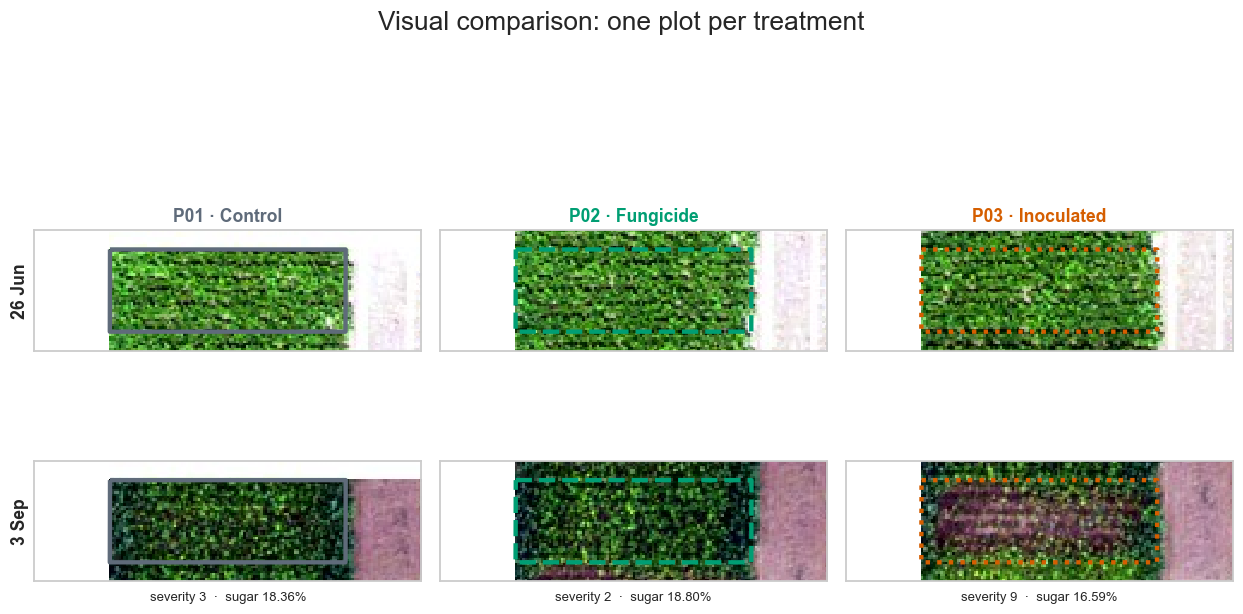

In [8]:
representatives = ["P01", "P02", "P03"]  # all from Block 1
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for col, plot_id in enumerate(representatives):
    record = field.set_index("plot_id").loc[plot_id]
    for row_i, (image, geo, date) in enumerate([
        (rgb_early, plots_early, "26 Jun"),
        (rgb_late, plots_late, "3 Sep"),
    ]):
        ax = axes[row_i, col]
        shape = geo.set_index("plot_id").loc[plot_id].geometry
        x0, y0, x1, y1 = shape.bounds
        padx, pady = max(8, (x1-x0)*.32), max(8, (y1-y0)*.22)
        rgb_axis(ax, image)
        geo[geo.plot_id == plot_id].boundary.plot(
            ax=ax,
            color=COLORS[str(record.treatment)],
            linestyle=LINESTYLES[str(record.treatment)],
            linewidth=3,
        )
        ax.set(xlim=(x0-padx, x1+padx), ylim=(y1+pady, y0-pady))
        if row_i == 0:
            ax.set_title(
                f"{plot_id} · {record.treatment}",
                color=COLORS[str(record.treatment)],
            )
        if col == 0:
            ax.set_ylabel(date, fontsize=12, weight="bold")
        if row_i == 1:
            ax.text(
                .5,
                -.08,
                f"severity {record.severity_sep04:g}  ·  sugar {record.sugar_content_pct:.2f}%",
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=9,
            )
fig.suptitle("Visual comparison: one plot per treatment", fontsize=18)
plt.tight_layout(rect=(0, 0, 1, .94))
plt.show()

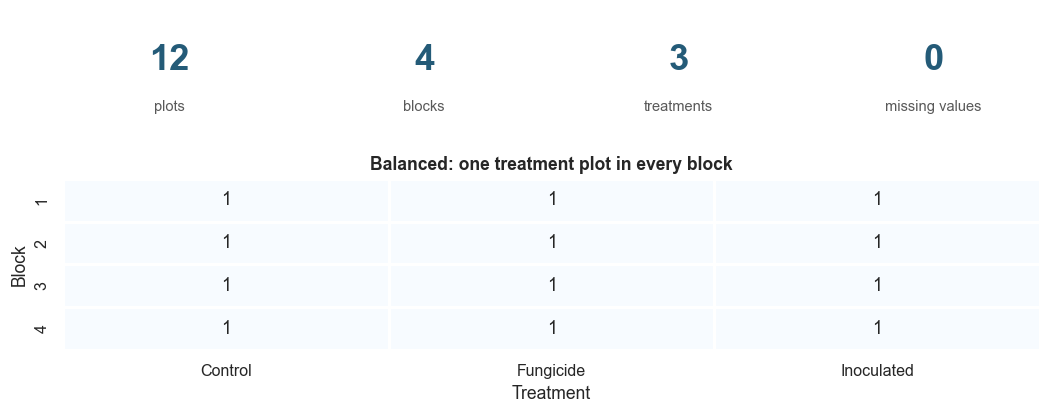

In [9]:
# A 20-second data audit.
facts = [
    (len(field), "plots"),
    (field.block.nunique(), "blocks"),
    (field.treatment.nunique(), "treatments"),
    (int(field.isna().sum().sum()), "missing values"),
]
balance = pd.crosstab(field.block, field.treatment).reindex(columns=ORDER)

fig = plt.figure(figsize=(12, 4.2))
grid = fig.add_gridspec(2, 4, height_ratios=[1, 1.45], hspace=.35)
for i, (value, label) in enumerate(facts):
    ax = fig.add_subplot(grid[0, i])
    ax.axis("off")
    ax.text(
        .5, .58, str(value), ha="center", va="center",
        fontsize=25, weight="bold", color="#245B78",
    )
    ax.text(.5, .18, label, ha="center", va="center", fontsize=10, color=".35")
ax = fig.add_subplot(grid[1, :])
sns.heatmap(
    balance,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="white",
    ax=ax,
)
ax.set(
    xlabel="Treatment",
    ylabel="Block",
    title="Balanced: one treatment plot in every block",
)
plt.show()

**Audit:** The plot is the experimental unit. Sugar content is
continuous, severity is ordered, and June green share is numeric but
post-inoculation/same-day-as-fungicide. The four blocks protect the
treatment comparison from broad field-position differences.

## 2 · Choose the method from the question

**Reveal: C — the blocked treatment model.** It compares a continuous
outcome across treatments and respects the design without conditioning
on a post-treatment image descriptor. D is still useful—but only as a
conditional ANCOVA sensitivity analysis.

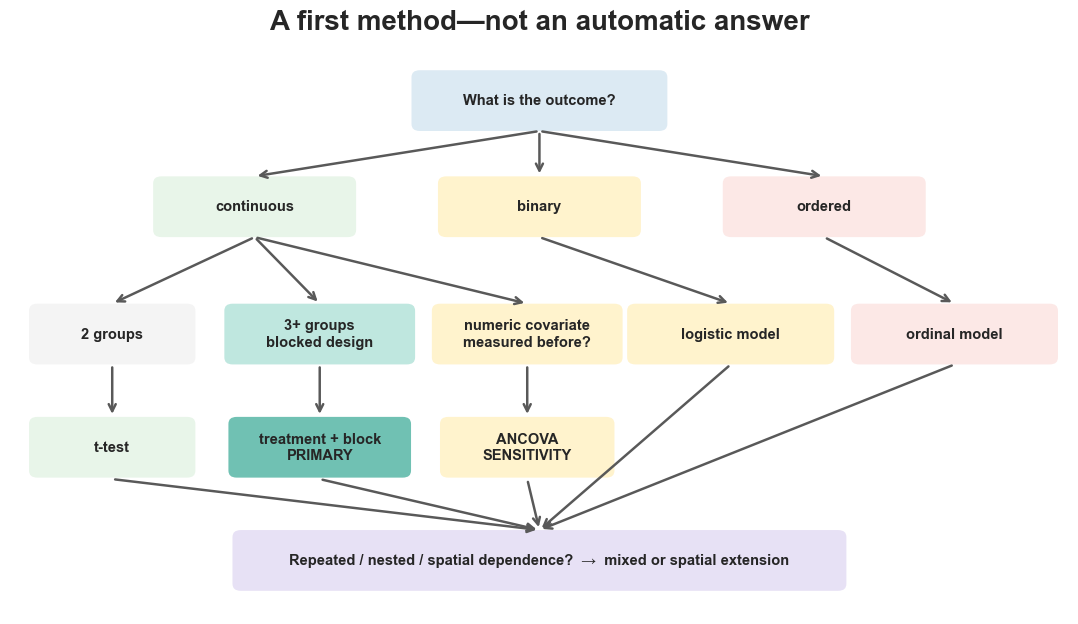

In [10]:
# A deliberately simple decision tree. Design can still override this first choice.
fig, ax = plt.subplots(figsize=(13, 7))
ax.set(xlim=(0, 13), ylim=(0, 8))
ax.axis("off")

def box_at(x, y, text, color, width=2.45, height=.82, size=10):
    patch = FancyBboxPatch(
        (x-width/2, y-height/2),
        width,
        height,
        boxstyle="round,pad=.04,rounding_size=.12",
        facecolor=color,
        edgecolor="white",
        linewidth=2,
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=size, weight="bold")

def arrow(a, b):
    ax.annotate(
        "",
        xy=b,
        xytext=a,
        arrowprops=dict(arrowstyle="->", lw=1.7, color=".35"),
    )

box_at(6.5, 7.25, "What is the outcome?", "#DCEAF3", 3.1)
box_at(3.0, 5.75, "continuous", "#E8F5E9")
box_at(6.5, 5.75, "binary", "#FFF3CD")
box_at(10.0, 5.75, "ordered", "#FCE8E6")
for x in (3, 6.5, 10):
    arrow((6.5, 6.82), (x, 6.18))

box_at(1.25, 3.95, "2 groups", "#F4F4F4", 2.0)
box_at(3.8, 3.95, "3+ groups\nblocked design", "#BFE7DF", 2.3)
box_at(6.35, 3.95, "numeric covariate\nmeasured before?", "#FFF3CD", 2.3)
for x in (1.25, 3.8, 6.35):
    arrow((3, 5.32), (x, 4.38))
box_at(1.25, 2.35, "t-test", "#E8F5E9", 2.0)
box_at(3.8, 2.35, "treatment + block\nPRIMARY", "#70C1B3", 2.2)
box_at(6.35, 2.35, "ANCOVA\nSENSITIVITY", "#FFF3CD", 2.1)
arrow((1.25, 3.52), (1.25, 2.78))
arrow((3.8, 3.52), (3.8, 2.78))
arrow((6.35, 3.52), (6.35, 2.78))

box_at(8.85, 3.95, "logistic model", "#FFF3CD", 2.5)
box_at(11.6, 3.95, "ordinal model", "#FCE8E6", 2.5)
arrow((6.5, 5.32), (8.85, 4.38))
arrow((10, 5.32), (11.6, 4.38))

box_at(
    6.5,
    .75,
    "Repeated / nested / spatial dependence?  →  mixed or spatial extension",
    "#E7E1F5",
    7.5,
)
for x in (1.25, 3.8, 6.35, 8.85, 11.6):
    arrow((x, 1.9 if x < 7 else 3.52), (6.5, 1.18))
ax.set_title("A first method—not an automatic answer", fontsize=19, pad=12)
plt.show()

**Transfer:** No. Severity is ordered, so an ordinal model is the natural first family. Repeated dates would also require a repeated or mixed extension.

### Today’s question

**Primary:** Within Aluco, do treatments differ in sugar content after accounting for field block?

**Sensitivity:** How does the numerical answer change if we condition on June green share?

> **Inference guardrail:** all Aluco plots were included because Aluco
> has low CLS resistance. This is a within-cultivar trial comparison,
> not a claim about all cultivars. Total-effect causal language also
> depends on negligible interference and faithful implementation.

In [11]:
field["green_c"] = field.early_green_share - field.early_green_share.mean()
field["block"] = pd.Categorical(field["block"])

primary_model = smf.ols(
    "sugar_content_pct ~ C(treatment) + C(block)",
    data=field,
).fit()
ancova_model = smf.ols(
    "sugar_content_pct ~ C(treatment) + C(block) + green_c",
    data=field,
).fit()
model = primary_model
tests = anova_lm(model, typ=2).rename(columns={"sum_sq": "SS", "PR(>F)": "p"})
display(
    tests[["SS", "df", "F", "p"]]
    .round(4)
    .style.background_gradient(subset=["F"], cmap="Blues")
    .format({"p": lambda x: "" if pd.isna(x) else f"{x:.4g}"})
)

primary_tests = anova_lm(primary_model, typ=2)
ancova_tests = anova_lm(ancova_model, typ=2)
sensitivity = pd.DataFrame([
    {
        "question": "Primary total comparison",
        "model": "treatment + block",
        "treatment F": primary_tests.loc["C(treatment)", "F"],
        "treatment p": primary_tests.loc["C(treatment)", "PR(>F)"],
        "June-green p": np.nan,
        "residual df": primary_model.df_resid,
    },
    {
        "question": "Conditional sensitivity",
        "model": "+ June green share",
        "treatment F": ancova_tests.loc["C(treatment)", "F"],
        "treatment p": ancova_tests.loc["C(treatment)", "PR(>F)"],
        "June-green p": ancova_tests.loc["green_c", "PR(>F)"],
        "residual df": ancova_model.df_resid,
    },
])
display(sensitivity.round(4).style.hide(axis="index"))

,SS,df,F,p
C(treatment),11.044100,2.000000,299.524000,0
C(block),0.121400,3.000000,2.194800,0.1896
Residual,0.110600,6.000000,nan,


question,model,treatment F,treatment p,June-green p,residual df
Primary total comparison,treatment + block,299.524000,0.000000,nan,6.000000
Conditional sensitivity,+ June green share,260.775800,0.000000,0.608400,5.000000


<details>
<summary><strong>Why this model?</strong></summary>

Block stays in the model because it belongs to the design—not because its p-value is small.
The ANCOVA is displayed because timing can change an estimand: a
post-treatment covariate is not made valid by a large p-value.
Type II tests are obtained with
<a href="https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html">statsmodels anova_lm</a>.
A p-value is not effect size or scientific importance:
<a href="https://doi.org/10.1080/00031305.2016.1154108">ASA statement on p-values</a>.
</details>

### Assumptions: check the model, not a ritual

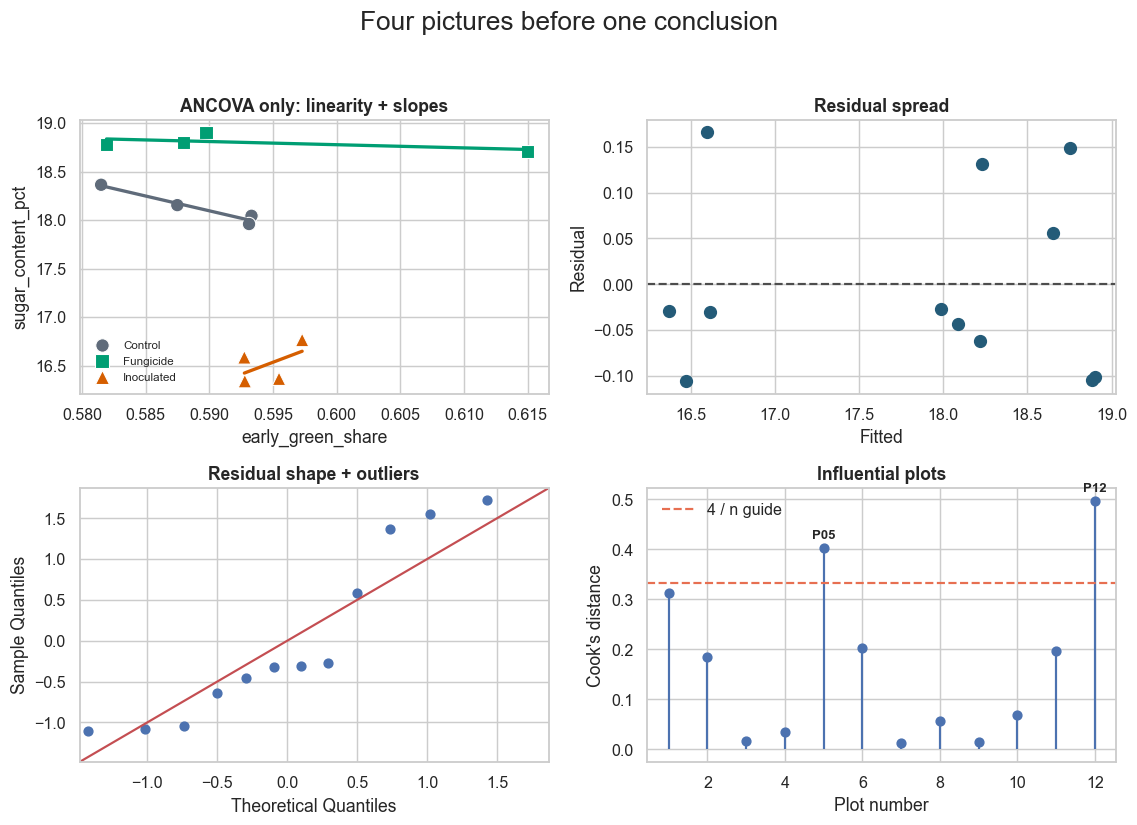

Assumption,How to check,If doubtful
independent experimental units,randomization + no interference,mixed / grouped model
ANCOVA: linear covariate relation,scatter + residual plot,transform or nonlinear term
ANCOVA: same covariate slope,interaction p = 0.526,keep interaction
similar residual spread,plot + BP p = 0.643,rethink variance / outcome model
residual shape / outliers,Q–Q + Shapiro p = 0.044,inspect + robust method
no unexplained spatial pattern,residual map next,spatial model / redesign


Tiny n: pictures + design knowledge matter more than a pass/fail p-value checklist.


In [12]:
interaction = smf.ols(
    "sugar_content_pct ~ C(treatment) * green_c + C(block)",
    data=field,
).fit()
slope_p = float(anova_lm(ancova_model, interaction).iloc[1]["Pr(>F)"])
# F version is preferred here because the LM version can overstate
# evidence in small samples.
bp_p = float(het_breuschpagan(model.resid, model.model.exog)[3])
shapiro_p = float(shapiro(model.resid).pvalue)
influence = model.get_influence()
cooks = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for treatment, group in field.groupby("treatment", observed=True):
    sns.regplot(
        data=group,
        x="early_green_share",
        y="sugar_content_pct",
        scatter=False,
        color=COLORS[str(treatment)],
        ci=None,
        truncate=True,
        ax=axes[0, 0],
    )
sns.scatterplot(
    data=field,
    x="early_green_share",
    y="sugar_content_pct",
    hue="treatment",
    style="treatment",
    palette=COLORS,
    markers=MARKERS,
    s=85,
    ax=axes[0, 0],
)
axes[0, 0].set_title("ANCOVA only: linearity + slopes")
axes[0, 0].legend(frameon=False, fontsize=8)

axes[0, 1].scatter(model.fittedvalues, model.resid, c="#245B78", s=65)
axes[0, 1].axhline(0, color=".3", ls="--")
axes[0, 1].set(xlabel="Fitted", ylabel="Residual", title="Residual spread")

sm.qqplot(model.resid, line="45", fit=True, ax=axes[1, 0])
axes[1, 0].set_title("Residual shape + outliers")

axes[1, 1].stem(np.arange(1, len(field)+1), cooks, basefmt=" ")
axes[1, 1].axhline(4/len(field), color="#E76F51", ls="--", label="4 / n guide")
for index, value in enumerate(cooks):
    if value > 4/len(field):
        axes[1, 1].text(
            index + 1,
            value + .018,
            field.iloc[index].plot_id,
            ha="center",
            fontsize=9,
            weight="bold",
        )
axes[1, 1].set(
    xlabel="Plot number",
    ylabel="Cook's distance",
    title="Influential plots",
)
axes[1, 1].legend(frameon=False)
fig.suptitle("Four pictures before one conclusion", fontsize=18)
plt.tight_layout(rect=(0, 0, 1, .95))
plt.show()

checks = pd.DataFrame({
    "Assumption": [
        "independent experimental units",
        "ANCOVA: linear covariate relation",
        "ANCOVA: same covariate slope",
        "similar residual spread",
        "residual shape / outliers",
        "no unexplained spatial pattern",
    ],
    "How to check": [
        "randomization + no interference",
        "scatter + residual plot",
        f"interaction p = {slope_p:.3f}",
        f"plot + BP p = {bp_p:.3f}",
        f"Q–Q + Shapiro p = {shapiro_p:.3f}",
        "residual map next",
    ],
    "If doubtful": [
        "mixed / grouped model",
        "transform or nonlinear term",
        "keep interaction",
        "rethink variance / outcome model",
        "inspect + robust method",
        "spatial model / redesign",
    ],
})
display(checks.style.hide(axis="index").set_properties(**{"text-align": "left"}))
print("Tiny n: pictures + design knowledge matter more than a pass/fail p-value checklist.")

**Class decision: WARNING !** The primary blocked model respects the
recorded design, but the Q–Q shape, influential P05/P12, only 12 plots,
and six residual degrees of freedom make inference fragile. The ANCOVA
checks do not repair its post-treatment timing. A diagnostic p-value
never certifies an assumption.

<details>
<summary><strong>Why not “assumptions passed”?</strong></summary>

Independence comes from design and sampling, not a residual test. With this tiny sample,
interaction, Breusch–Pagan, and Shapiro tests have limited diagnostic value.
See the official
<a href="https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.het_breuschpagan.html">Breusch–Pagan documentation</a>.
</details>

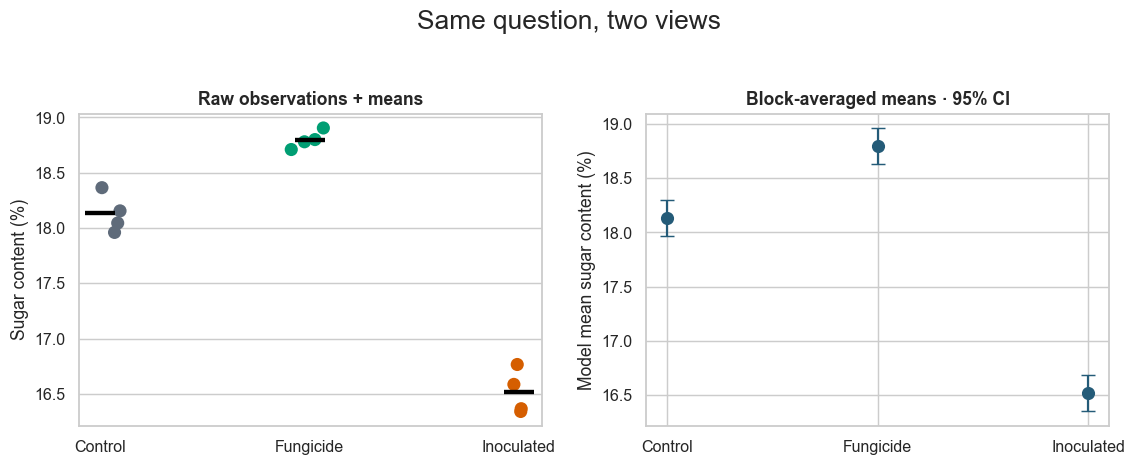

treatment,mean,low,high
Control,18.131000,17.965000,18.297000
Fungicide,18.799000,18.633000,18.965000
Inoculated,16.514000,16.348000,16.680000


In [13]:
# Block-averaged model means from the primary blocked model.
from scipy.stats import t as student_t
import patsy

new = pd.DataFrame(
    [(treatment, block) for treatment in ORDER for block in [1, 2, 3, 4]],
    columns=["treatment", "block"],
)
design = model.model.data.design_info
exog_grid = np.asarray(patsy.build_design_matrices([design], new)[0])
average_exog = np.stack(
    [exog_grid[i*4:(i+1)*4].mean(axis=0) for i in range(len(ORDER))]
)
covariance = model.cov_params().to_numpy()
critical = student_t.ppf(.975, model.df_resid)

adjusted_rows = []
for treatment, vector in zip(ORDER, average_exog):
    mean = float(vector @ model.params)
    se = float(np.sqrt(vector @ covariance @ vector))
    adjusted_rows.append({
        "treatment": treatment,
        "mean": mean,
        "low": mean - critical*se,
        "high": mean + critical*se,
    })
adjusted = pd.DataFrame(adjusted_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.stripplot(
    data=field,
    x="treatment",
    y="sugar_content_pct",
    order=ORDER,
    palette=COLORS,
    hue="treatment",
    legend=False,
    jitter=.10,
    size=9,
    ax=axes[0],
)
raw_means = field.groupby("treatment", observed=True).sugar_content_pct.mean().reindex(ORDER)
axes[0].scatter(
    np.arange(len(ORDER)), raw_means,
    marker="_", s=420, linewidth=3, color="black", zorder=5,
)
axes[0].set(
    xlabel="",
    ylabel="Sugar content (%)",
    title="Raw observations + means",
)

x = np.arange(3)
axes[1].errorbar(
    x,
    adjusted["mean"],
    yerr=[
        adjusted["mean"]-adjusted["low"],
        adjusted["high"]-adjusted["mean"],
    ],
    fmt="o",
    color="#245B78",
    ecolor="#245B78",
    capsize=5,
    ms=8,
)
axes[1].set(
    xticks=x,
    xticklabels=ORDER,
    ylabel="Model mean sugar content (%)",
    title="Block-averaged means · 95% CI",
)
fig.suptitle("Same question, two views", fontsize=18)
plt.tight_layout(rect=(0, 0, 1, .94))
plt.show()
display(adjusted.round(3).style.hide(axis="index"))

## 3 · Post hoc: which comparisons, and why?

**Reveal: B.** Dunnett is the specialized control-comparison procedure. Here we demonstrate two control-focused contrasts from the fitted blocked model and apply Holm to that explicitly specified two-comparison family.

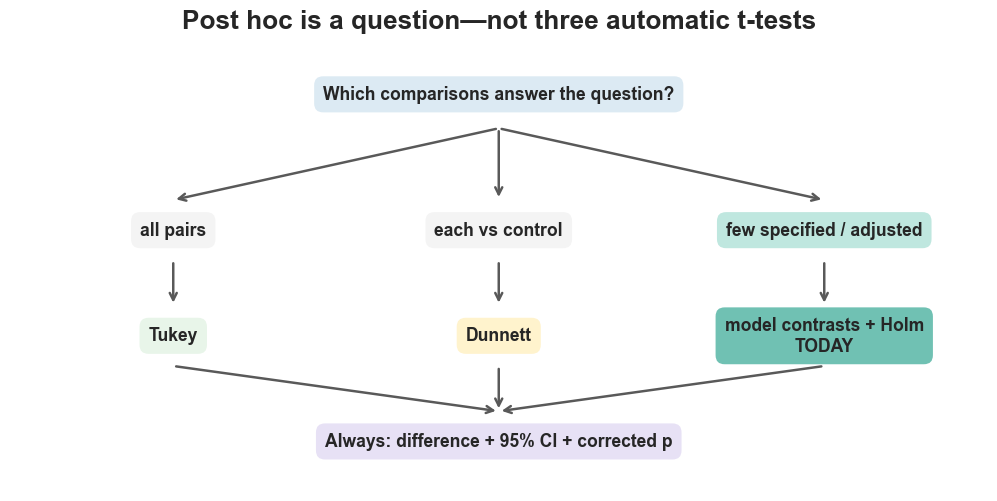

In [14]:
fig, ax = plt.subplots(figsize=(12, 5.6))
ax.set(xlim=(0, 12), ylim=(0, 6))
ax.axis("off")

def pbox(x, y, text, color):
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        weight="bold",
        bbox=dict(boxstyle="round,pad=.6", fc=color, ec="white", lw=2),
    )

def parr(a, b):
    ax.annotate(
        "",
        xy=b,
        xytext=a,
        arrowprops=dict(arrowstyle="->", lw=1.7, color=".35"),
    )

pbox(6, 5.25, "Which comparisons answer the question?", "#DCEAF3")
pbox(2, 3.45, "all pairs", "#F4F4F4")
pbox(6, 3.45, "each vs control", "#F4F4F4")
pbox(10, 3.45, "few specified / adjusted", "#BFE7DF")
for x in (2, 6, 10):
    parr((6, 4.8), (x, 3.85))
pbox(2, 2.05, "Tukey", "#E8F5E9")
pbox(6, 2.05, "Dunnett", "#FFF3CD")
pbox(10, 2.05, "model contrasts + Holm\nTODAY", "#70C1B3")
for x in (2, 6, 10):
    parr((x, 3.05), (x, 2.45))
pbox(6, .65, "Always: difference + 95% CI + corrected p", "#E7E1F5")
for x in (2, 6, 10):
    parr((x, 1.65), (6, 1.05))
ax.set_title("Post hoc is a question—not three automatic t-tests", fontsize=18)
plt.show()

> **Post hoc inherits the model assumptions.** Do not re-test each pair with separate assumptions or uncorrected t-tests. Choose comparisons in advance when possible; correct the family of comparisons you actually make.

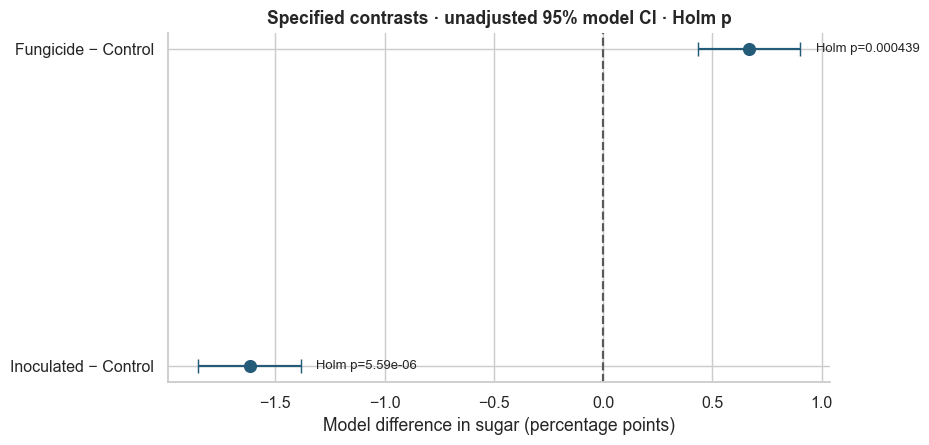

contrast,difference,low,high,p_holm
Fungicide − Control,0.667500,0.432600,0.902400,0.000400
Inoculated − Control,-1.617500,-1.852400,-1.382600,0.000000


In [15]:
# Two control-focused contrasts specified before viewing their results.
pairs = [
    ("Fungicide", "Control", 1, 0),
    ("Inoculated", "Control", 2, 0),
]
rows = []
for first, second, i, j in pairs:
    result = model.t_test(average_exog[i] - average_exog[j])
    ci = np.asarray(result.conf_int())[0]
    rows.append({
        "contrast": f"{first} − {second}",
        "difference": np.asarray(result.effect).item(),
        "low": np.asarray(ci[0]).item(),
        "high": np.asarray(ci[1]).item(),
        "p_raw": np.asarray(result.pvalue).item(),
    })
contrasts = pd.DataFrame(rows)
contrasts["p_holm"] = multipletests(contrasts.p_raw, method="holm")[1]

fig, ax = plt.subplots(figsize=(9, 4.4))
y = np.arange(len(contrasts))[::-1]
ax.axvline(0, color=".35", ls="--")
ax.errorbar(
    contrasts.difference,
    y,
    xerr=[
        contrasts.difference-contrasts.low,
        contrasts.high-contrasts.difference,
    ],
    fmt="o",
    color="#245B78",
    capsize=5,
    ms=8,
)
for yi, (_, row) in zip(y, contrasts.iterrows()):
    ax.text(
        row.high + .07,
        yi,
        f"Holm p={row.p_holm:.3g}",
        va="center",
        fontsize=9,
    )
ax.set(
    yticks=y,
    yticklabels=contrasts.contrast,
    xlabel="Model difference in sugar (percentage points)",
    title="Specified contrasts · unadjusted 95% model CI · Holm p",
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
display(
    contrasts[["contrast", "difference", "low", "high", "p_holm"]]
    .round(4)
    .style.hide(axis="index")
)

<details>
<summary><strong>Why these post hoc choices?</strong></summary>

All pairs → <a href="https://doi.org/10.2307/3001913">Tukey</a>.
Treatments vs one control → <a href="https://doi.org/10.1080/01621459.1955.10501294">Dunnett</a>.
A specified contrast family can use
<a href="https://doi.org/10.2307/4615733">Holm correction</a>.
The intervals shown here are ordinary model-based 95% intervals; only the p-values are Holm-adjusted.
</details>

### Spatial check: did the model leave a pattern?

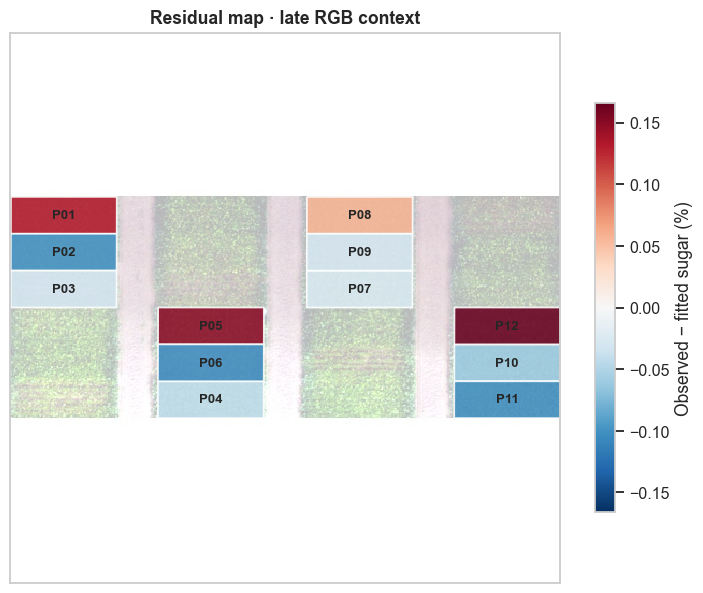

Pixel coordinates only. This map is a visual diagnostic—not a spatial model or proof of independence.


In [16]:
residual_map = plots_late.copy()
residual_map["residual"] = model.resid.to_numpy()
limit = max(abs(residual_map.residual.min()), abs(residual_map.residual.max()))

fig, ax = plt.subplots(figsize=(7, 6))
rgb_axis(ax, rgb_late, "Residual map · late RGB context")
ax.images[0].set_alpha(.28)
residual_map.plot(
    ax=ax,
    column="residual",
    cmap="RdBu_r",
    alpha=.88,
    norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit),
    edgecolor="white",
    linewidth=1.2,
    legend=True,
    legend_kwds={"label": "Observed − fitted sugar (%)", "shrink": .7},
)
for _, row in residual_map.iterrows():
    c = row.geometry.centroid
    ax.text(
        c.x, c.y, row.plot_id,
        ha="center", va="center", fontsize=9, weight="bold",
    )
ax.set(xlim=(0, 512), ylim=(512, 0), xticks=[], yticks=[])
plt.tight_layout()
plt.show()
print("Pixel coordinates only. This map is a visual diagnostic—not a spatial model or proof of independence.")

**Evidence:** Inoculated has the lowest block-averaged model mean. The two control-focused contrasts show direction, magnitude in percentage points, model-based uncertainty, and Holm-adjusted evidence for the specified two-comparison family.

## 4 · Evaluate the CNN like a scientist

The architecture was covered elsewhere. Here the CNN is a **measurement candidate**.

**24 real crop cases = 12 plots × 2 dates.** In every fold, one complete block is held out.

**Reveal: B.** Holding out a complete block keeps both dates and all plots from that spatial group out of training. A random crop split could put closely related views of the same field structure on both sides.

### Manual step-through · move the fold slider, then rerun

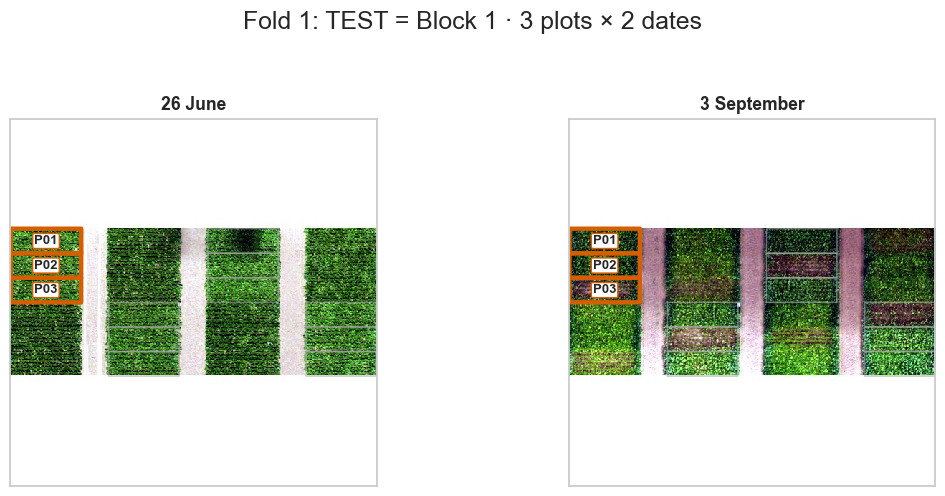

In [17]:
fold_to_inspect = 1  # @param {"type":"slider","min":1,"max":4,"step":1}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, image, geo, date in [
    (axes[0], rgb_early, plots_early, "26 June"),
    (axes[1], rgb_late, plots_late, "3 September"),
]:
    rgb_axis(ax, image, date)
    geo.boundary.plot(ax=ax, color="0.65", linewidth=1, alpha=.65)
    held_out = geo[geo.block.astype(int).eq(fold_to_inspect)]
    held_out.boundary.plot(ax=ax, color="#D55E00", linewidth=3)
    for _, row in held_out.iterrows():
        point = row.geometry.centroid
        ax.text(
            point.x, point.y, row.plot_id,
            ha="center", va="center", fontsize=9, weight="bold",
            bbox=dict(boxstyle="round,pad=.12", fc="white", ec="#D55E00"),
        )
fig.suptitle(
    f"Fold {fold_to_inspect}: TEST = Block {fold_to_inspect} · 3 plots × 2 dates",
    fontsize=17,
)
plt.tight_layout(rect=(0, 0, 1, .93))
plt.show()

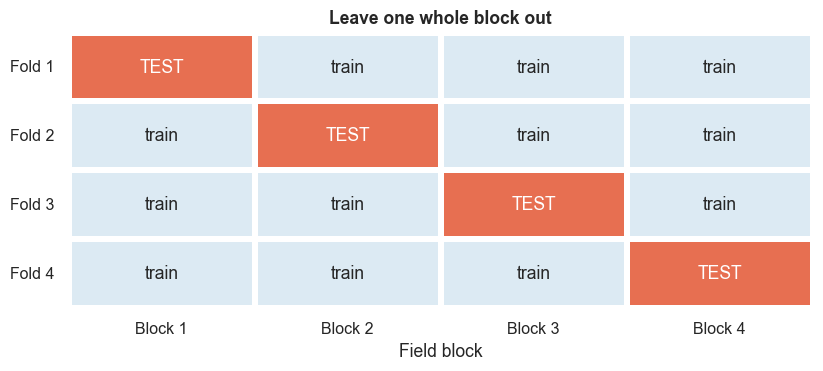

Why? Crops from the test block never appear in that fold's training data → less spatial leakage.


In [18]:
split = np.ones((4, 4), dtype=int)
np.fill_diagonal(split, 2)
fig, ax = plt.subplots(figsize=(8, 3.7))
sns.heatmap(
    split,
    cmap=sns.color_palette(["#DCEAF3", "#E76F51"], as_cmap=True),
    cbar=False,
    linewidths=3,
    linecolor="white",
    ax=ax,
    annot=np.where(split == 2, "TEST", "train"),
    fmt="",
)
ax.set(
    xticklabels=["Block 1", "Block 2", "Block 3", "Block 4"],
    yticklabels=["Fold 1", "Fold 2", "Fold 3", "Fold 4"],
    xlabel="Field block",
    ylabel="",
    title="Leave one whole block out",
)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()
print("Why? Crops from the test block never appear in that fold's training data → less spatial leakage.")

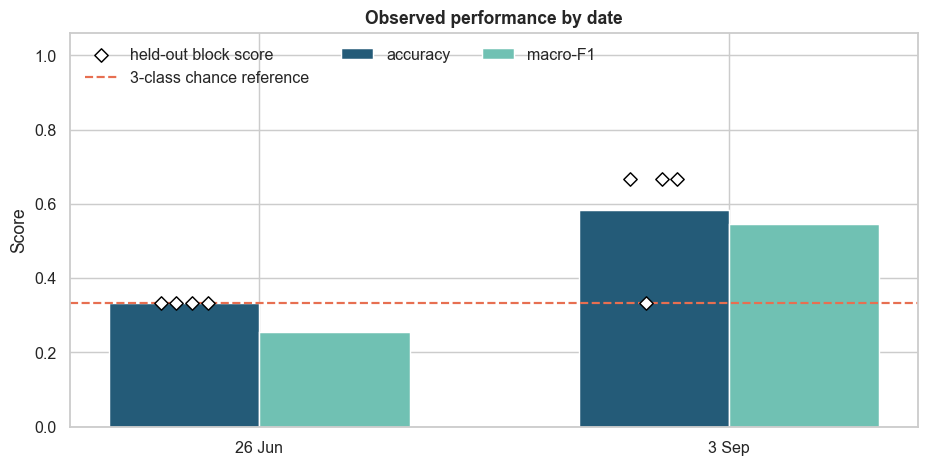

date,n,correct,accuracy,macro_F1
2020-06-26,12,4,0.333000,0.256000
2020-09-03,12,7,0.583000,0.544000


Descriptive total: 11/24 correct = 45.8%. The 24 rows repeat 12 plots; only four blocks are held out.


In [19]:
metric_rows = []
for date, group in cnn.groupby("date", sort=True):
    correct = int((group.true_class == group.cnn_prediction).sum())
    metric_rows.append({
        "date": date,
        "n": len(group),
        "correct": correct,
        "accuracy": accuracy_score(group.true_class, group.cnn_prediction),
        "macro_F1": f1_score(
            group.true_class,
            group.cnn_prediction,
            labels=ORDER,
            average="macro",
            zero_division=0,
        ),
    })
metrics = pd.DataFrame(metric_rows)
all_correct = int((cnn.true_class == cnn.cnn_prediction).sum())
cnn["correct"] = (cnn.true_class == cnn.cnn_prediction).astype(int)
block_scores = (
    cnn.groupby(["date", "held_out_block"], as_index=False)
    .correct.mean()
)

x = np.arange(len(metrics))
width = .32
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(x-width/2, metrics.accuracy, width, label="accuracy", color="#245B78")
ax.bar(x+width/2, metrics.macro_F1, width, label="macro-F1", color="#70C1B3")
for index, date in enumerate(metrics.date):
    values = block_scores.loc[block_scores.date.eq(date), "correct"]
    offsets = np.linspace(-.05, .05, len(values))
    ax.scatter(
        np.full(len(values), x[index]-width/2) + offsets,
        values,
        marker="D",
        s=42,
        facecolor="white",
        edgecolor="black",
        zorder=4,
        label="held-out block score" if index == 0 else None,
    )
ax.axhline(1/3, color="#E76F51", ls="--", label="3-class chance reference")
ax.set(
    xticks=x,
    xticklabels=["26 Jun", "3 Sep"],
    ylim=(0, 1.06),
    ylabel="Score",
    title="Observed performance by date",
)
ax.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()
display(metrics.round(3).style.hide(axis="index"))
print(
    f"Descriptive total: {all_correct}/{len(cnn)} correct = {all_correct/len(cnn):.1%}. "
    "The 24 rows repeat 12 plots; only four blocks are held out."
)

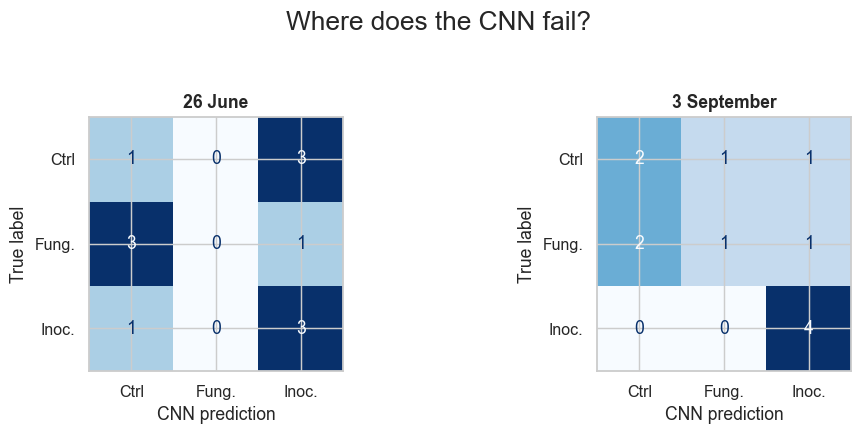

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (date, group) in zip(axes, cnn.groupby("date", sort=True)):
    ConfusionMatrixDisplay.from_predictions(
        group.true_class,
        group.cnn_prediction,
        labels=ORDER,
        display_labels=["Ctrl", "Fung.", "Inoc."],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title("26 June" if date == "2020-06-26" else "3 September")
    ax.set_xlabel("CNN prediction")
fig.suptitle("Where does the CNN fail?", fontsize=18)
plt.tight_layout(rect=(0, 0, 1, .93))
plt.show()

<details>
<summary><strong>Why no confidence interval around 11/24?</strong></summary>

The 24 rows are not 24 independent field units: the same 12 plots appear twice and
the four cross-validation fits share training data. Counts, block-level points, and
confusion matrices are honest descriptive evidence; they are not a generalization interval.
See <a href="https://doi.org/10.1111/ecog.02881">Roberts et al. on structured cross-validation</a>
and the official <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html">GroupKFold documentation</a>.
</details>

**Decision:** No. Grouped evaluation is preferable to a random crop split, but only 4/12 June and 7/12 September crops were correct, with just four held-out blocks. Accuracy was higher in September in this set; that does not establish a date effect. Next, test a frozen model on more independent blocks, cultivars, seasons, and acquisition conditions.

## 5 · Results ≠ Discussion

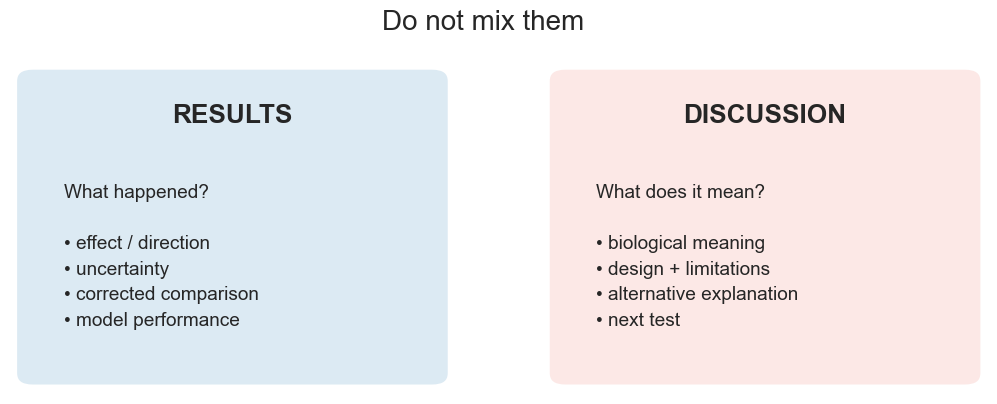

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cards = [
    (
        axes[0],
        "RESULTS",
        "What happened?\n\n• effect / direction\n• uncertainty\n• corrected comparison\n• model performance",
        "#DCEAF3",
    ),
    (
        axes[1],
        "DISCUSSION",
        "What does it mean?\n\n• biological meaning\n• design + limitations\n• alternative explanation\n• next test",
        "#FCE8E6",
    ),
]
for ax, title, body, color in cards:
    ax.axis("off")
    ax.add_patch(
        FancyBboxPatch(
            (.04, .05),
            .92,
            .88,
            transform=ax.transAxes,
            boxstyle="round,pad=.03,rounding_size=.04",
            fc=color,
            ec="white",
            lw=3,
        )
    )
    ax.text(
        .5, .82, title,
        transform=ax.transAxes,
        ha="center", va="center", fontsize=18, weight="bold",
    )
    ax.text(
        .12, .62, body,
        transform=ax.transAxes,
        ha="left", va="top", fontsize=13, linespacing=1.55,
    )
fig.suptitle("Do not mix them", fontsize=19)
plt.show()

### CARD SORT · Reveal

| Card | Class |
|---|:---:|
| Treatment: F(2,6) = 299.5, p < .001 | **R** |
| Inoculated − Control = −1.62 percentage points | **R** |
| September CNN: 7/12 correct | **R** |
| The subset contains one low-resistance cultivar | **D** |
| The treatment caused the visible mechanism | **U** |
| Next: test independent seasons and cultivars | **D** |

### Example scientific conclusion

**Results.** Within all 12 Aluco plots, the blocked model estimated
mean sugar content of 18.13% for Control, 18.80% for Fungicide, and
16.51% for Inoculated, with both specified control contrasts supported
after Holm correction; leave-one-block-out evaluation classified 4/12
June and 7/12 September crops correctly.

**Discussion.** The treatment comparison applies to this low-resistance
cultivar and remains sensitive to interference and the tiny four-block
design; June green share is post-treatment, and a frozen CNN must be
tested on independent blocks, dates, seasons, and cultivars.

## Exit ticket

1. **One claim this subset permits:** …
2. **One claim this subset does not permit:** …

**Optional / homework:** run a CNN example from
[Nathan Okole’s Introduction to Programming](https://github.com/nathanokole/Introduction-to-programming),
then bring its **true labels, predictions, and grouping variable** into this evaluation workflow.
Use the repository’s [vibe-coding verification guide](../instructor/vibe_coding_extension.md):
AI may draft code or prose; design, assertions, and evidence decide whether it is acceptable.